# Analysis

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score

In [18]:
def extract_mean(value):
    if isinstance(value, str):
        return float(value.split('$\\pm$')[0])
    else:
        return value
def bar_plot(data: pd.DataFrame, Title: str):
    data = data.copy()
    for column in data.columns:
        data[column] = data[column].apply(extract_mean)

    plt.figure(figsize=(16, 8))
    plt.xticks(rotation=90)
    bar_width = 0.12
    r = np.arange(len(data))
    for i, metric in enumerate(data.columns):
        plt.bar(r + i * bar_width, data[metric], width=bar_width, label=metric)
    plt.xlabel('Methods', fontweight='bold')
    plt.xticks(r + bar_width * (len(data.columns) - 1) / 2, data.index)
    plt.ylabel('Scores')
    plt.title(Title)
    plt.ylim(0, 100)
    plt.legend(title='Metrics', loc='center right')
    plt.tight_layout()
    plt.show()

def heatmap(data: pd.DataFrame, Title: str, normalized=True):
    data = data.copy()
    data = data.T
    if 'pretrain_time' in data.index:
        data = data.drop('pretrain_time')
    for column in data.columns:
        data[column] = data[column].apply(extract_mean).apply(np.mean)
    if normalized:
        normalized_data = (data - data.min(axis=1).values[:, np.newaxis]) / (data.max(axis=1).values[:, np.newaxis] - data.min(axis=1).values[:, np.newaxis])
    else:
        normalized_data = data
    fig, ax = plt.subplots(figsize=(12, 12))
    im = ax.imshow(normalized_data)
    
    plt.xticks(rotation=90)
    
    ax.set_yticks(range(len(data.index)), labels=data.index,
                  rotation=45, ha="right", rotation_mode="anchor")
    ax.set_xticks(range(len(data.columns)), labels=data.columns)
    
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            text_color = 'white' if normalized_data.iloc[i, j] < np.mean(normalized_data) else 'black'
            text = ax.text(j, i, f"{data.iloc[i, j]:.2f}",
                           ha="center", va="center", color=text_color)
    
    ax.set_title(Title)
    fig.tight_layout()
    plt.show()

## Cora

Cora
\begin{tabular}{llllll}
\toprule
Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
\midrule
36.73$\pm$2.73 & 42.36$\pm$2.1 & 49.86$\pm$1.61 & 58.35$\pm$1.48 & 84.3$\pm$0.69 & nan$\pm$nan \\
12.41$\pm$2.3 & 19.02$\pm$2.18 & 29.45$\pm$2.31 & 41.23$\pm$1.77 & 77.86$\pm$0.57 & nan$\pm$nan \\
35.86$\pm$1.31 & 39.59$\pm$1.97 & 46.97$\pm$2.61 & 57.1$\pm$3.21 & 85.94$\pm$0.74 & 26.57$\pm$1.07 \\
13.92$\pm$2.97 & 21.27$\pm$2.78 & 33.44$\pm$2.04 & 47.05$\pm$1.88 & 82.9$\pm$0.7 & 26.26$\pm$0.86 \\
36.84$\pm$3.03 & 41.08$\pm$3.12 & 47.8$\pm$2.98 & 54.31$\pm$3.0 & 79.56$\pm$2.2 & 28.48$\pm$2.03 \\
12.77$\pm$2.63 & 18.87$\pm$3.42 & 28.59$\pm$3.35 & 39.69$\pm$3.57 & 75.7$\pm$3.71 & 37.92$\pm$6.85 \\
36.85$\pm$2.49 & 41.58$\pm$3.58 & 48.19$\pm$4.13 & 54.86$\pm$4.6 & 81.28$\pm$2.94 & 42.46$\pm$3.54 \\
13.55$\pm$2.97 & 17.99$\pm$2.72 & 29.13$\pm$3.53 & 41.27$\pm$4.08 & 77.48$\pm$4.09 & 37.98$\pm$5.88 \\
36.74$\pm$2.77 & 41.23$\pm$3.42 & 48.41$\pm$3.92 & 55.75$\pm$4.68 & 81.51$\pm$3

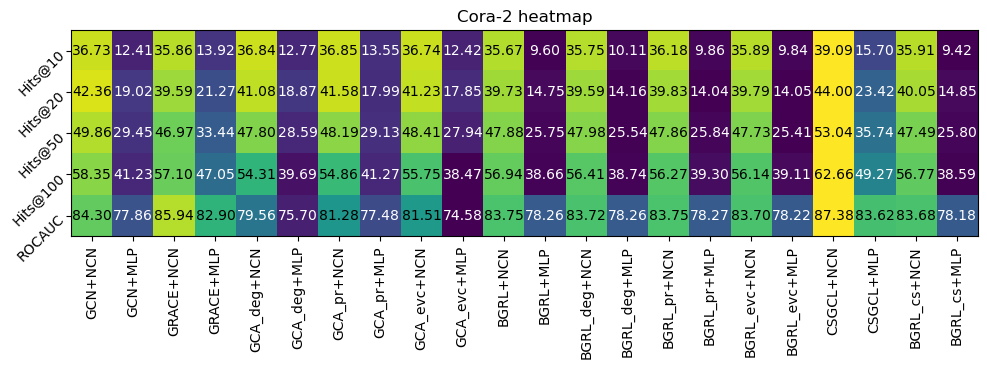

In [6]:
datac2 = pd.read_csv('./Cora-2_res.csv', sep=';').T
datac2.columns = datac2.loc['metrics']
datac2.drop(index='metrics', inplace=True)
datac2.index = datac2.index.str.replace('Cora ', '', regex=False)
print('Cora')
print(datac2.to_latex(
        index=False, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(datac2, 'Cora-2 heatmap')

Cora
\begin{tabular}{llllll}
\toprule
Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
\midrule
37.5$\pm$2.78 & 42.72$\pm$2.23 & 50.5$\pm$1.33 & 58.85$\pm$1.11 & 84.79$\pm$0.69 & nan$\pm$nan \\
12.82$\pm$2.51 & 18.93$\pm$2.29 & 29.11$\pm$2.3 & 41.65$\pm$2.11 & 78.44$\pm$0.57 & nan$\pm$nan \\
35.44$\pm$2.25 & 39.56$\pm$2.08 & 48.15$\pm$2.85 & 58.7$\pm$3.19 & 86.82$\pm$1.1 & 41.91$\pm$8.06 \\
15.96$\pm$3.61 & 22.36$\pm$3.06 & 34.95$\pm$3.07 & 50.38$\pm$2.96 & 83.83$\pm$1.42 & 42.82$\pm$5.32 \\
36.2$\pm$3.66 & 39.24$\pm$4.35 & 45.31$\pm$5.26 & 52.89$\pm$4.8 & 81.64$\pm$2.25 & 41.33$\pm$4.2 \\
12.96$\pm$3.22 & 18.43$\pm$3.69 & 29.22$\pm$3.9 & 39.48$\pm$5.19 & 76.21$\pm$5.19 & 40.54$\pm$3.71 \\
35.66$\pm$2.37 & 39.48$\pm$3.26 & 45.65$\pm$3.48 & 53.1$\pm$2.74 & 80.51$\pm$1.78 & 43.1$\pm$4.17 \\
11.95$\pm$3.38 & 17.12$\pm$3.3 & 27.24$\pm$2.66 & 38.03$\pm$3.44 & 73.86$\pm$4.81 & 37.03$\pm$2.25 \\
35.49$\pm$1.79 & 39.61$\pm$4.59 & 46.32$\pm$5.16 & 54.13$\pm$5.23 & 81.44$\pm$4.

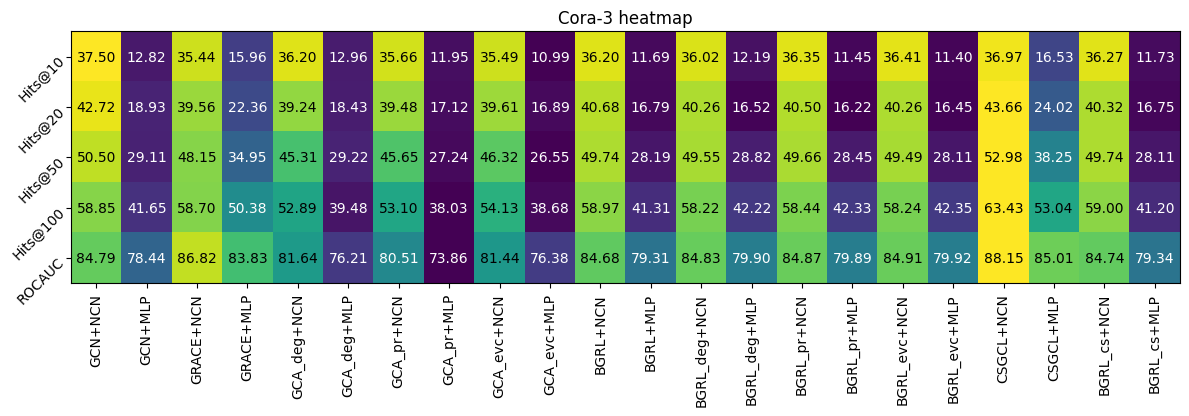

In [9]:
datac3 = pd.read_csv('./Cora-3_res.csv', sep=';').T
datac3.columns = datac3.loc['metrics']
datac3.drop(index='metrics', inplace=True)
datac3.index = datac3.index.str.replace('Cora ', '', regex=False)
print('Cora')
print(datac3.to_latex(
        index=False, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(datac3, 'Cora-3 heatmap')

Cora
\begin{tabular}{lllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
\midrule
GCN+NCN & 46.71$\pm$3.08 & 54.07$\pm$2.27 & 61.59$\pm$1.48 & 66.33$\pm$1.79 & 78.46$\pm$0.96 & nan$\pm$nan \\
GCN+MLP & 41.55$\pm$4.1 & 51.41$\pm$3.13 & 60.82$\pm$1.47 & 65.38$\pm$1.03 & 77.7$\pm$0.86 & nan$\pm$nan \\
GRACE+NCN & 46.73$\pm$2.55 & 52.99$\pm$1.07 & 58.17$\pm$1.02 & 62.19$\pm$1.64 & 78.85$\pm$2.39 & 46.47$\pm$4.35 \\
GRACE+MLP & 43.52$\pm$4.16 & 49.87$\pm$2.01 & 57.13$\pm$1.34 & 61.55$\pm$0.86 & 76.63$\pm$0.86 & 43.9$\pm$3.6 \\
GCA_deg+NCN & 40.06$\pm$3.81 & 48.58$\pm$3.38 & 57.84$\pm$1.91 & 63.36$\pm$1.82 & 77.8$\pm$1.2 & 42.11$\pm$4.11 \\
GCA_deg+MLP & 39.59$\pm$4.72 & 48.57$\pm$2.83 & 58.08$\pm$1.58 & 63.61$\pm$1.5 & 79.97$\pm$1.45 & 41.9$\pm$4.54 \\
GCA_pr+NCN & 47.15$\pm$2.35 & 52.66$\pm$1.78 & 58.11$\pm$0.96 & 62.18$\pm$1.44 & 78.09$\pm$1.42 & 43.09$\pm$4.32 \\
GCA_pr+MLP & 41.36$\pm$3.35 & 48.28$\pm$2.13 & 55.51$\pm$1.48 & 60.07$\pm$1.33 & 74

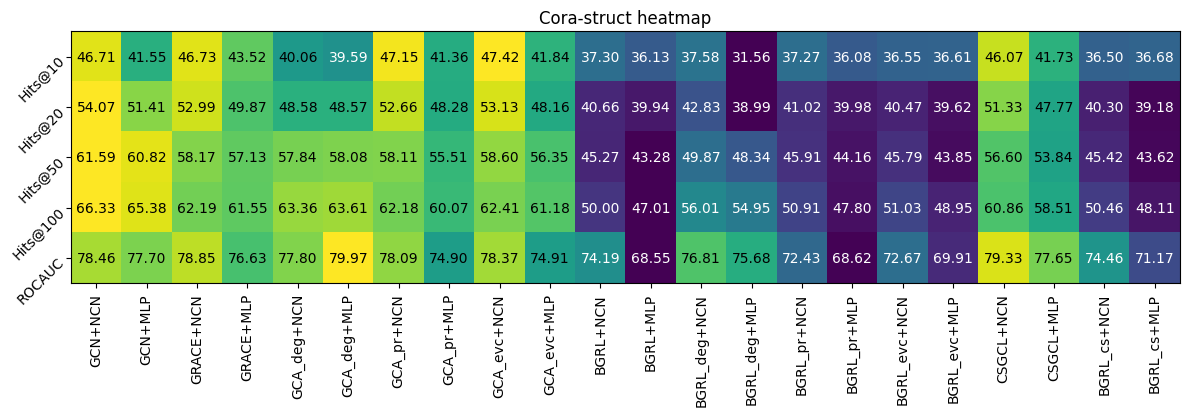

In [10]:
datac_struct = pd.read_csv('./Cora-struct_res.csv', sep=';').T
datac_struct.columns = datac_struct.loc['metrics']
datac_struct.drop(index='metrics', inplace=True)
datac_struct.index = datac_struct.index.str.replace('Cora ', '', regex=False)
print('Cora')
print(datac_struct.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(datac_struct, 'Cora-struct heatmap')

Cora
\begin{tabular}{llllll}
\toprule
Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
\midrule
50.9$\pm$0.0 & 64.36$\pm$0.0 & 81.8$\pm$0.0 & 89.1$\pm$0.0 & 95.51$\pm$0.0 & nan$\pm$nan \\
53.84$\pm$0.0 & 60.95$\pm$0.0 & 78.77$\pm$0.0 & 85.5$\pm$0.0 & 94.99$\pm$0.0 & nan$\pm$nan \\
43.13$\pm$0.0 & 54.69$\pm$0.0 & 67.49$\pm$0.0 & 77.63$\pm$0.0 & 91.56$\pm$0.0 & 26.78$\pm$0.0 \\
43.79$\pm$0.0 & 58.67$\pm$0.0 & 67.01$\pm$0.0 & 74.98$\pm$0.0 & 89.22$\pm$0.0 & 25.91$\pm$0.0 \\
37.63$\pm$0.0 & 49.29$\pm$0.0 & 66.92$\pm$0.0 & 81.99$\pm$0.0 & 93.14$\pm$0.0 & 26.45$\pm$0.0 \\
32.61$\pm$0.0 & 41.14$\pm$0.0 & 66.92$\pm$0.0 & 82.27$\pm$0.0 & 92.5$\pm$0.0 & 25.89$\pm$0.0 \\
41.23$\pm$0.0 & 49.29$\pm$0.0 & 67.39$\pm$0.0 & 80.95$\pm$0.0 & 93.36$\pm$0.0 & 27.46$\pm$0.0 \\
27.2$\pm$0.0 & 46.73$\pm$0.0 & 69.29$\pm$0.0 & 80.09$\pm$0.0 & 92.38$\pm$0.0 & 27.65$\pm$0.0 \\
36.68$\pm$0.0 & 49.0$\pm$0.0 & 69.0$\pm$0.0 & 79.24$\pm$0.0 & 92.64$\pm$0.0 & 26.82$\pm$0.0 \\
31.66$\pm$0.0 & 43.7$\pm$

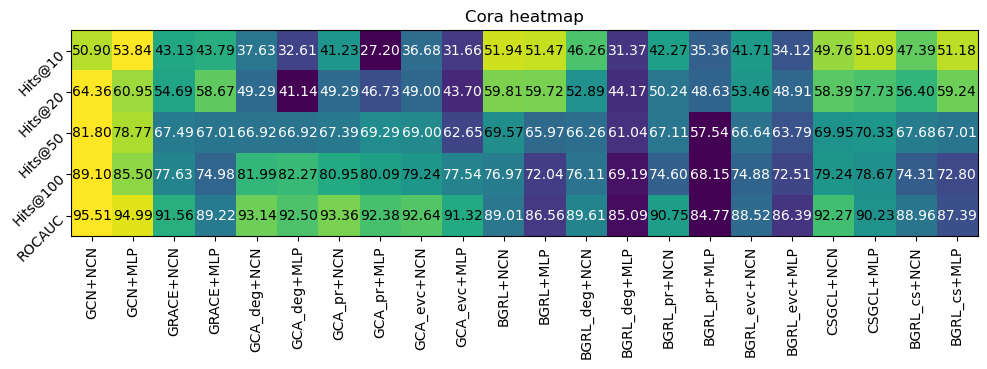

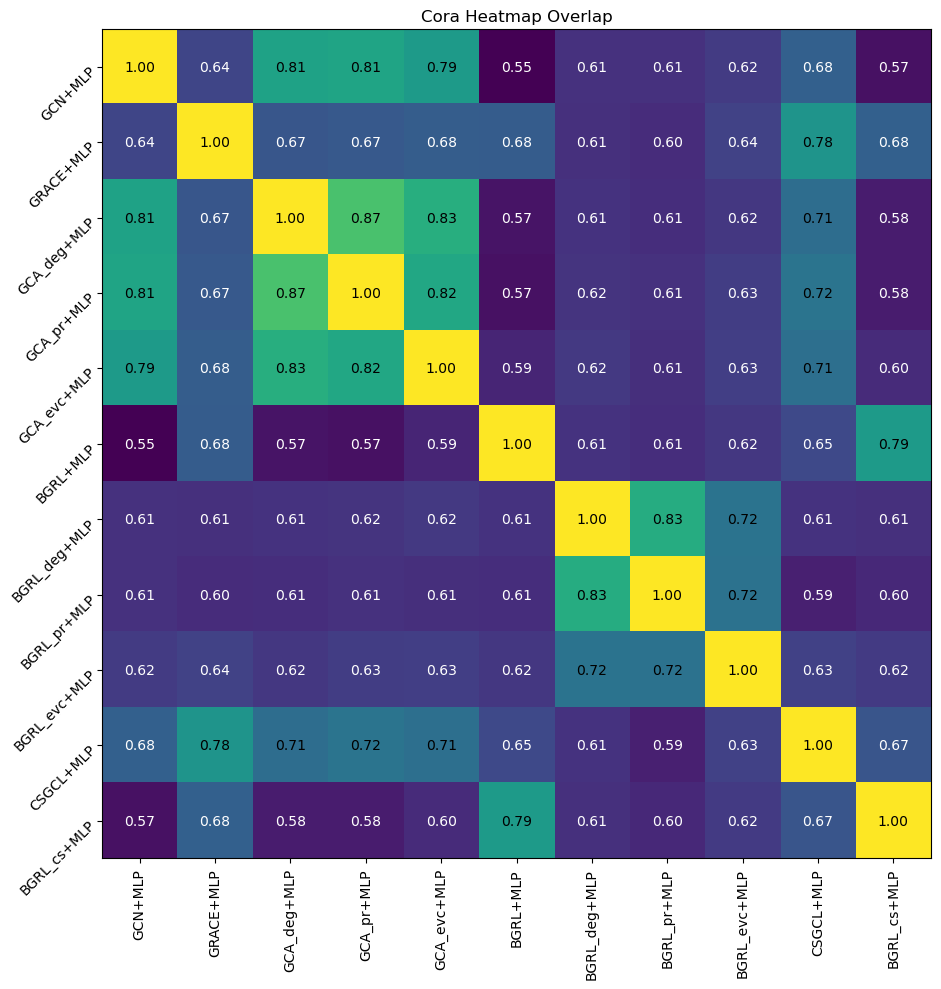

In [7]:
# Overlaps
data = pd.read_csv('./Cora_res.csv', sep=';').T
data.columns = data.loc['metrics']
data.drop(index='metrics', inplace=True)
pred = data['test_pred'].apply(ast.literal_eval)
pred.index = pred.index.str.replace('Cora ', '', regex=False)

data.drop(columns='test_pred', inplace=True)
data.index = data.index.str.replace('Cora ', '', regex=False)
print('Cora')
print(data.to_latex(
        index=False, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data, 'Cora heatmap')
def jaccard_sim(data1, data2):
    data1 = np.array(data1)
    data2 = np.array(data2)
    # data1 = (data1 - data1.min()) / (data1.max() - data1.min())
    # data2 = (data2 - data2.min()) / (data2.max() - data2.min())
    return jaccard_score([x>0.5 for x in data1], [x>0.5 for x in data2])

def jaccard_heatmap(data):
    data = data[~data.index.str.contains('NCN')]
    res = np.zeros((len(data), len(data)))
    for idx in range(len(data)):
        for idx2 in range(len(data)):
            if idx < idx2:
                res[idx][idx2] = jaccard_sim(data.iloc[idx], data.iloc[idx2])
    res += np.transpose(res) + np.identity(len(data))
    heatmap(pd.DataFrame(res, index=data.index, columns=data.index), 'Cora Heatmap Overlap', False)

jaccard_heatmap(pred)

## Citeseer

In [8]:
data0 = pd.read_csv('./Citeseer_res.csv', sep=';').T
data0.columns = data0.loc['metrics']
data0.drop(index='metrics', inplace=True)
data0.index = data0.index.str.replace('Citeseer ', '', regex=False)
print('Citeseer')
print(data0.to_latex(
        index=False, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
data0

Citeseer
\begin{tabular}{lllll}
\toprule
Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC \\
\midrule
69.45$\pm$4.93 & 78.29$\pm$3.76 & 87.3$\pm$1.82 & 92.58$\pm$0.97 & 96.94$\pm$0.38 \\
70.07$\pm$4.62 & 78.02$\pm$2.69 & 86.21$\pm$1.05 & 91.67$\pm$0.71 & 96.93$\pm$0.35 \\
59.05$\pm$2.76 & 66.42$\pm$1.75 & 75.03$\pm$1.86 & 82.24$\pm$1.89 & 92.21$\pm$0.91 \\
59.0$\pm$3.93 & 66.45$\pm$2.23 & 74.02$\pm$1.53 & 80.89$\pm$0.93 & 92.32$\pm$0.52 \\
56.21$\pm$6.0 & 64.51$\pm$5.01 & 77.44$\pm$3.17 & 84.22$\pm$3.55 & 93.1$\pm$1.29 \\
53.75$\pm$8.25 & 62.29$\pm$5.22 & 75.25$\pm$4.27 & 82.89$\pm$3.76 & 92.91$\pm$1.2 \\
58.54$\pm$3.07 & 65.35$\pm$2.64 & 75.14$\pm$2.17 & 82.05$\pm$1.59 & 92.04$\pm$0.69 \\
57.71$\pm$2.88 & 64.69$\pm$2.21 & 73.73$\pm$1.37 & 80.55$\pm$1.2 & 91.87$\pm$0.63 \\
58.82$\pm$2.42 & 66.64$\pm$2.01 & 74.62$\pm$1.94 & 81.32$\pm$1.14 & 91.91$\pm$0.61 \\
59.32$\pm$2.39 & 64.84$\pm$1.98 & 72.66$\pm$1.27 & 79.88$\pm$1.32 & 91.92$\pm$0.71 \\
70.65$\pm$2.74 & 75.03$\pm$1.85 & 80.44$\pm$1

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC
GCN+NCN,69.45$\pm$4.93,78.29$\pm$3.76,87.3$\pm$1.82,92.58$\pm$0.97,96.94$\pm$0.38
GCN+MLP,70.07$\pm$4.62,78.02$\pm$2.69,86.21$\pm$1.05,91.67$\pm$0.71,96.93$\pm$0.35
GRACE+NCN,59.05$\pm$2.76,66.42$\pm$1.75,75.03$\pm$1.86,82.24$\pm$1.89,92.21$\pm$0.91
GRACE+MLP,59.0$\pm$3.93,66.45$\pm$2.23,74.02$\pm$1.53,80.89$\pm$0.93,92.32$\pm$0.52
GCA_deg+NCN,56.21$\pm$6.0,64.51$\pm$5.01,77.44$\pm$3.17,84.22$\pm$3.55,93.1$\pm$1.29
GCA_deg+MLP,53.75$\pm$8.25,62.29$\pm$5.22,75.25$\pm$4.27,82.89$\pm$3.76,92.91$\pm$1.2
GCA_pr+NCN,58.54$\pm$3.07,65.35$\pm$2.64,75.14$\pm$2.17,82.05$\pm$1.59,92.04$\pm$0.69
GCA_pr+MLP,57.71$\pm$2.88,64.69$\pm$2.21,73.73$\pm$1.37,80.55$\pm$1.2,91.87$\pm$0.63
GCA_evc+NCN,58.82$\pm$2.42,66.64$\pm$2.01,74.62$\pm$1.94,81.32$\pm$1.14,91.91$\pm$0.61
GCA_evc+MLP,59.32$\pm$2.39,64.84$\pm$1.98,72.66$\pm$1.27,79.88$\pm$1.32,91.92$\pm$0.71


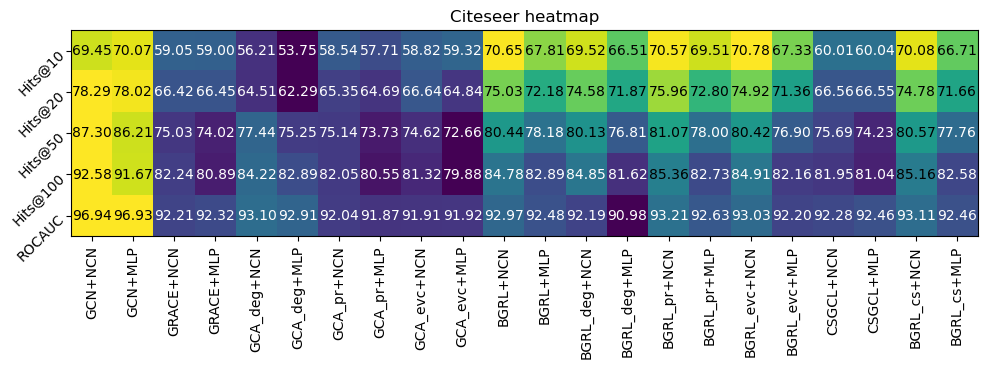

In [9]:
heatmap(data0, 'Citeseer heatmap')

## Citeseer Only Features

In [10]:
data1 = pd.read_csv('./Citeseer-feature_res.csv', sep=';').T
data1.columns = data1.loc['metrics']
data1.drop(index='metrics', inplace=True)
data1.index = data1.index.str.replace('Citeseer ', '', regex=False)
print('Citeseer-feature')
print(data1.to_latex(
        index=False, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
data1

Citeseer-feature
\begin{tabular}{lllll}
\toprule
Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC \\
\midrule
66.18$\pm$5.57 & 74.95$\pm$3.42 & 86.42$\pm$1.66 & 91.49$\pm$0.99 & 96.58$\pm$0.45 \\
64.14$\pm$6.47 & 72.75$\pm$3.89 & 83.71$\pm$1.08 & 90.67$\pm$1.08 & 96.5$\pm$0.4 \\
37.92$\pm$3.79 & 47.37$\pm$2.93 & 60.27$\pm$2.62 & 72.55$\pm$2.43 & 89.67$\pm$0.71 \\
35.78$\pm$4.72 & 43.45$\pm$3.55 & 57.07$\pm$3.15 & 68.27$\pm$2.07 & 88.32$\pm$0.95 \\
34.52$\pm$6.53 & 44.56$\pm$5.03 & 59.49$\pm$2.66 & 72.29$\pm$2.72 & 89.61$\pm$0.91 \\
30.66$\pm$3.78 & 40.71$\pm$3.52 & 54.99$\pm$2.34 & 67.57$\pm$2.04 & 88.09$\pm$1.03 \\
34.52$\pm$6.53 & 44.56$\pm$5.03 & 59.49$\pm$2.66 & 72.29$\pm$2.72 & 89.61$\pm$0.91 \\
30.66$\pm$3.78 & 40.71$\pm$3.52 & 54.99$\pm$2.34 & 67.57$\pm$2.04 & 88.09$\pm$1.03 \\
34.52$\pm$6.53 & 44.56$\pm$5.03 & 59.49$\pm$2.66 & 72.29$\pm$2.72 & 89.61$\pm$0.91 \\
30.66$\pm$3.78 & 40.71$\pm$3.52 & 54.99$\pm$2.34 & 67.57$\pm$2.04 & 88.09$\pm$1.03 \\
46.19$\pm$3.55 & 52.02$\pm$4.28 &

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC
GCN+NCN,66.18$\pm$5.57,74.95$\pm$3.42,86.42$\pm$1.66,91.49$\pm$0.99,96.58$\pm$0.45
GCN+MLP,64.14$\pm$6.47,72.75$\pm$3.89,83.71$\pm$1.08,90.67$\pm$1.08,96.5$\pm$0.4
GRACE+NCN,37.92$\pm$3.79,47.37$\pm$2.93,60.27$\pm$2.62,72.55$\pm$2.43,89.67$\pm$0.71
GRACE+MLP,35.78$\pm$4.72,43.45$\pm$3.55,57.07$\pm$3.15,68.27$\pm$2.07,88.32$\pm$0.95
GCA_deg+NCN,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91
GCA_deg+MLP,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03
GCA_pr+NCN,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91
GCA_pr+MLP,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03
GCA_evc+NCN,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91
GCA_evc+MLP,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03


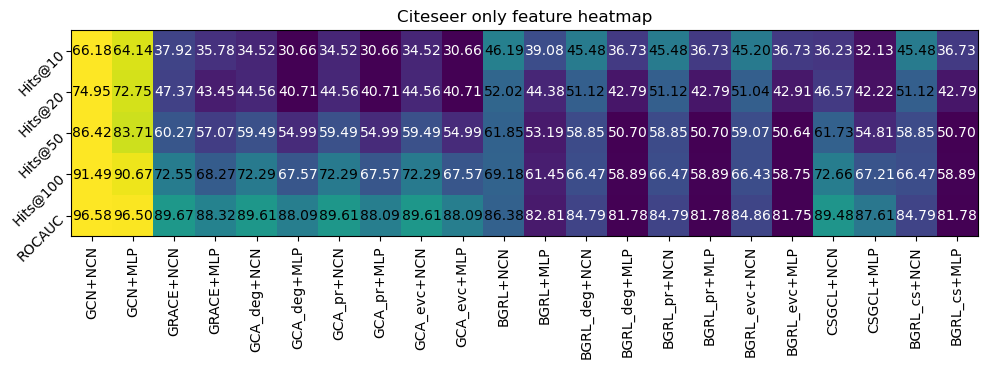

In [11]:
heatmap(data1, 'Citeseer only feature heatmap')

## Citeseer Only Structure

In [10]:
data2 = pd.read_csv('./Citeseer-structure_res.csv', sep=';').T
data2.columns = data2.loc['metrics']
data2.drop(index='metrics', inplace=True)
data2.index = data2.index.str.replace('Citeseer ', '', regex=False)
print('Citeseer-structure')
print(data2.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
data2

Citeseer-structure
\begin{tabular}{llllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC \\
\midrule
GCN+NCN & 31.38$\pm$1.32 & 33.66$\pm$1.09 & 39.26$\pm$1.03 & 44.65$\pm$1.05 & 72.44$\pm$0.96 \\
GCN+MLP & 9.05$\pm$1.72 & 12.47$\pm$1.13 & 20.23$\pm$1.22 & 27.78$\pm$1.17 & 62.53$\pm$1.22 \\
GRACE+NCN & 32.18$\pm$1.78 & 34.92$\pm$1.55 & 39.75$\pm$1.24 & 45.12$\pm$1.73 & 72.78$\pm$1.42 \\
GRACE+MLP & 10.99$\pm$1.49 & 15.27$\pm$1.39 & 22.66$\pm$1.21 & 30.78$\pm$1.85 & 65.27$\pm$1.4 \\
GCA_deg+NCN & 32.31$\pm$1.41 & 35.02$\pm$1.07 & 40.33$\pm$0.7 & 45.74$\pm$1.3 & 73.14$\pm$0.95 \\
GCA_deg+MLP & 9.95$\pm$3.82 & 13.31$\pm$4.77 & 20.0$\pm$6.78 & 27.51$\pm$9.41 & 63.28$\pm$4.65 \\
GCA_pr+NCN & 32.12$\pm$1.64 & 34.48$\pm$0.92 & 39.97$\pm$1.01 & 45.56$\pm$1.59 & 72.88$\pm$0.96 \\
GCA_pr+MLP & 8.26$\pm$4.33 & 11.69$\pm$5.89 & 17.93$\pm$9.01 & 24.31$\pm$12.27 & 61.79$\pm$5.98 \\
GCA_evc+NCN & 31.05$\pm$1.37 & 34.04$\pm$1.43 & 39.21$\pm$1.31 & 44.43$\pm$1.37 & 72.23$\pm$0.82 \

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC
GCN+NCN,31.38$\pm$1.32,33.66$\pm$1.09,39.26$\pm$1.03,44.65$\pm$1.05,72.44$\pm$0.96
GCN+MLP,9.05$\pm$1.72,12.47$\pm$1.13,20.23$\pm$1.22,27.78$\pm$1.17,62.53$\pm$1.22
GRACE+NCN,32.18$\pm$1.78,34.92$\pm$1.55,39.75$\pm$1.24,45.12$\pm$1.73,72.78$\pm$1.42
GRACE+MLP,10.99$\pm$1.49,15.27$\pm$1.39,22.66$\pm$1.21,30.78$\pm$1.85,65.27$\pm$1.4
GCA_deg+NCN,32.31$\pm$1.41,35.02$\pm$1.07,40.33$\pm$0.7,45.74$\pm$1.3,73.14$\pm$0.95
GCA_deg+MLP,9.95$\pm$3.82,13.31$\pm$4.77,20.0$\pm$6.78,27.51$\pm$9.41,63.28$\pm$4.65
GCA_pr+NCN,32.12$\pm$1.64,34.48$\pm$0.92,39.97$\pm$1.01,45.56$\pm$1.59,72.88$\pm$0.96
GCA_pr+MLP,8.26$\pm$4.33,11.69$\pm$5.89,17.93$\pm$9.01,24.31$\pm$12.27,61.79$\pm$5.98
GCA_evc+NCN,31.05$\pm$1.37,34.04$\pm$1.43,39.21$\pm$1.31,44.43$\pm$1.37,72.23$\pm$0.82
GCA_evc+MLP,8.34$\pm$4.42,11.13$\pm$5.81,17.44$\pm$8.76,24.08$\pm$12.07,61.51$\pm$5.82


In [12]:
citeseer = pd.concat([data0, data1, data2], axis=1)
print('citeseer final')
print(citeseer.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
citeseer

citeseer final
\begin{tabular}{llllllllllllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC \\
\midrule
GCN+NCN & 69.45$\pm$4.93 & 78.29$\pm$3.76 & 87.3$\pm$1.82 & 92.58$\pm$0.97 & 96.94$\pm$0.38 & 66.18$\pm$5.57 & 74.95$\pm$3.42 & 86.42$\pm$1.66 & 91.49$\pm$0.99 & 96.58$\pm$0.45 & 31.38$\pm$1.32 & 33.66$\pm$1.09 & 39.26$\pm$1.03 & 44.65$\pm$1.05 & 72.44$\pm$0.96 \\
GCN+MLP & 70.07$\pm$4.62 & 78.02$\pm$2.69 & 86.21$\pm$1.05 & 91.67$\pm$0.71 & 96.93$\pm$0.35 & 64.14$\pm$6.47 & 72.75$\pm$3.89 & 83.71$\pm$1.08 & 90.67$\pm$1.08 & 96.5$\pm$0.4 & 9.05$\pm$1.72 & 12.47$\pm$1.13 & 20.23$\pm$1.22 & 27.78$\pm$1.17 & 62.53$\pm$1.22 \\
GRACE+NCN & 59.05$\pm$2.76 & 66.42$\pm$1.75 & 75.03$\pm$1.86 & 82.24$\pm$1.89 & 92.21$\pm$0.91 & 37.92$\pm$3.79 & 47.37$\pm$2.93 & 60.27$\pm$2.62 & 72.55$\pm$2.43 & 89.67$\pm$0.71 & 32.18$\pm$1.78 & 34.92$\pm$1.55 & 39.75$\pm$1.24 & 45.12$\pm$1

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC
GCN+NCN,69.45$\pm$4.93,78.29$\pm$3.76,87.3$\pm$1.82,92.58$\pm$0.97,96.94$\pm$0.38,66.18$\pm$5.57,74.95$\pm$3.42,86.42$\pm$1.66,91.49$\pm$0.99,96.58$\pm$0.45,31.38$\pm$1.32,33.66$\pm$1.09,39.26$\pm$1.03,44.65$\pm$1.05,72.44$\pm$0.96
GCN+MLP,70.07$\pm$4.62,78.02$\pm$2.69,86.21$\pm$1.05,91.67$\pm$0.71,96.93$\pm$0.35,64.14$\pm$6.47,72.75$\pm$3.89,83.71$\pm$1.08,90.67$\pm$1.08,96.5$\pm$0.4,9.05$\pm$1.72,12.47$\pm$1.13,20.23$\pm$1.22,27.78$\pm$1.17,62.53$\pm$1.22
GRACE+NCN,59.05$\pm$2.76,66.42$\pm$1.75,75.03$\pm$1.86,82.24$\pm$1.89,92.21$\pm$0.91,37.92$\pm$3.79,47.37$\pm$2.93,60.27$\pm$2.62,72.55$\pm$2.43,89.67$\pm$0.71,32.18$\pm$1.78,34.92$\pm$1.55,39.75$\pm$1.24,45.12$\pm$1.73,72.78$\pm$1.42
GRACE+MLP,59.0$\pm$3.93,66.45$\pm$2.23,74.02$\pm$1.53,80.89$\pm$0.93,92.32$\pm$0.52,35.78$\pm$4.72,43.45$\pm$3.55,57.07$\pm$3.15,68.27$\pm$2.07,88.32$\pm$0.95,10.99$\pm$1.49,15.27$\pm$1.39,22.66$\pm$1.21,30.78$\pm$1.85,65.27$\pm$1.4
GCA_deg+NCN,56.21$\pm$6.0,64.51$\pm$5.01,77.44$\pm$3.17,84.22$\pm$3.55,93.1$\pm$1.29,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91,32.31$\pm$1.41,35.02$\pm$1.07,40.33$\pm$0.7,45.74$\pm$1.3,73.14$\pm$0.95
GCA_deg+MLP,53.75$\pm$8.25,62.29$\pm$5.22,75.25$\pm$4.27,82.89$\pm$3.76,92.91$\pm$1.2,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03,9.95$\pm$3.82,13.31$\pm$4.77,20.0$\pm$6.78,27.51$\pm$9.41,63.28$\pm$4.65
GCA_pr+NCN,58.54$\pm$3.07,65.35$\pm$2.64,75.14$\pm$2.17,82.05$\pm$1.59,92.04$\pm$0.69,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91,32.12$\pm$1.64,34.48$\pm$0.92,39.97$\pm$1.01,45.56$\pm$1.59,72.88$\pm$0.96
GCA_pr+MLP,57.71$\pm$2.88,64.69$\pm$2.21,73.73$\pm$1.37,80.55$\pm$1.2,91.87$\pm$0.63,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03,8.26$\pm$4.33,11.69$\pm$5.89,17.93$\pm$9.01,24.31$\pm$12.27,61.79$\pm$5.98
GCA_evc+NCN,58.82$\pm$2.42,66.64$\pm$2.01,74.62$\pm$1.94,81.32$\pm$1.14,91.91$\pm$0.61,34.52$\pm$6.53,44.56$\pm$5.03,59.49$\pm$2.66,72.29$\pm$2.72,89.61$\pm$0.91,31.05$\pm$1.37,34.04$\pm$1.43,39.21$\pm$1.31,44.43$\pm$1.37,72.23$\pm$0.82
GCA_evc+MLP,59.32$\pm$2.39,64.84$\pm$1.98,72.66$\pm$1.27,79.88$\pm$1.32,91.92$\pm$0.71,30.66$\pm$3.78,40.71$\pm$3.52,54.99$\pm$2.34,67.57$\pm$2.04,88.09$\pm$1.03,8.34$\pm$4.42,11.13$\pm$5.81,17.44$\pm$8.76,24.08$\pm$12.07,61.51$\pm$5.82


## Pubmed

Pubmed
\begin{tabular}{lllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
\midrule
GCN+NCN & 37.61$\pm$6.19 & 50.39$\pm$4.1 & 68.89$\pm$2.35 & 80.48$\pm$1.44 & 98.75$\pm$0.06 & nan$\pm$nan \\
GCN+MLP & 27.53$\pm$3.62 & 42.31$\pm$4.07 & 64.53$\pm$2.91 & 78.02$\pm$1.58 & 98.55$\pm$0.06 & nan$\pm$nan \\
GRACE+NCN & 36.45$\pm$5.08 & 47.83$\pm$4.38 & 64.46$\pm$2.92 & 75.61$\pm$1.83 & 98.03$\pm$0.09 & 418.47$\pm$0.38 \\
GRACE+MLP & 28.61$\pm$4.75 & 41.46$\pm$4.78 & 60.83$\pm$2.1 & 73.71$\pm$1.83 & 97.9$\pm$0.1 & 418.41$\pm$0.24 \\
BGRL+NCN & 37.03$\pm$4.9 & 47.97$\pm$2.62 & 63.92$\pm$2.15 & 74.18$\pm$1.18 & 97.56$\pm$0.1 & 28.7$\pm$0.27 \\
BGRL+MLP & 27.86$\pm$3.05 & 41.04$\pm$3.28 & 59.98$\pm$1.95 & 71.86$\pm$1.21 & 95.7$\pm$0.21 & 28.81$\pm$0.25 \\
BGRL_deg+NCN & 34.0$\pm$4.87 & 48.0$\pm$3.51 & 64.54$\pm$1.97 & 74.24$\pm$1.51 & 97.54$\pm$0.12 & 29.01$\pm$0.3 \\
BGRL_deg+MLP & 29.29$\pm$4.3 & 40.99$\pm$4.06 & 60.33$\pm$1.91 & 72.31$\pm$1.23 & 95.6

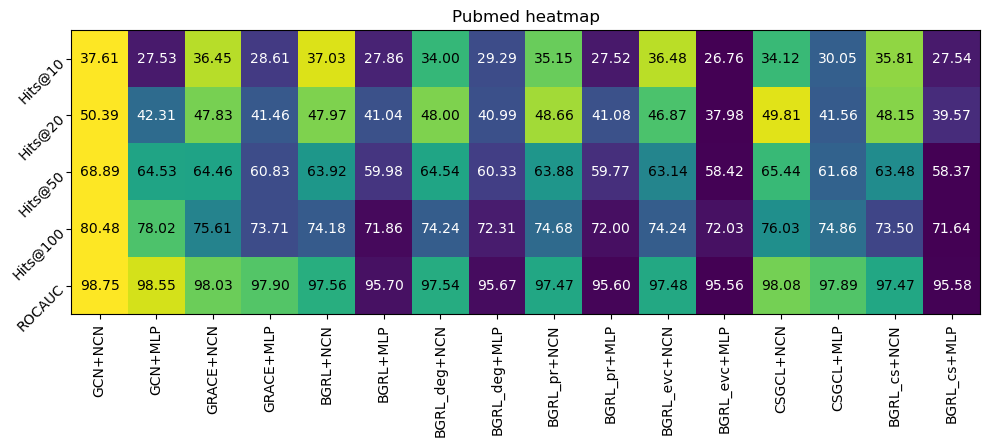

In [12]:
data3 = pd.read_csv('./Pubmed_res.csv', sep=';').T
data3.columns = data3.loc['metrics']
data3.drop(index='metrics', inplace=True)
data3.index = data3.index.str.replace('Pubmed ', '', regex=False)
print('Pubmed')
print(data3.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data3, 'Pubmed heatmap')

## ogbl-collab

collab
\begin{tabular}{lllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
\midrule
GCN+NCN & 43.61$\pm$1.25 & 55.71$\pm$0.64 & 63.53$\pm$0.39 & 66.94$\pm$0.14 & 96.82$\pm$0.06 & nan$\pm$nan \\
GCN+MLP & 17.44$\pm$2.08 & 24.14$\pm$1.94 & 34.88$\pm$1.95 & 43.83$\pm$1.49 & 97.45$\pm$0.05 & nan$\pm$nan \\
BGRL+NCN & 42.09$\pm$2.43 & 53.84$\pm$0.83 & 64.24$\pm$0.2 & 66.54$\pm$0.16 & 96.46$\pm$0.07 & 126.63$\pm$0.18 \\
BGRL+MLP & 5.62$\pm$0.87 & 10.36$\pm$0.98 & 18.55$\pm$1.21 & 26.16$\pm$0.76 & 96.3$\pm$0.05 & 126.66$\pm$0.09 \\
BGRL_cs+MLP & 6.31$\pm$1.09 & 10.14$\pm$1.6 & 17.32$\pm$1.38 & 24.93$\pm$1.2 & 96.25$\pm$0.12 & 137.7$\pm$0.3 \\
\bottomrule
\end{tabular}



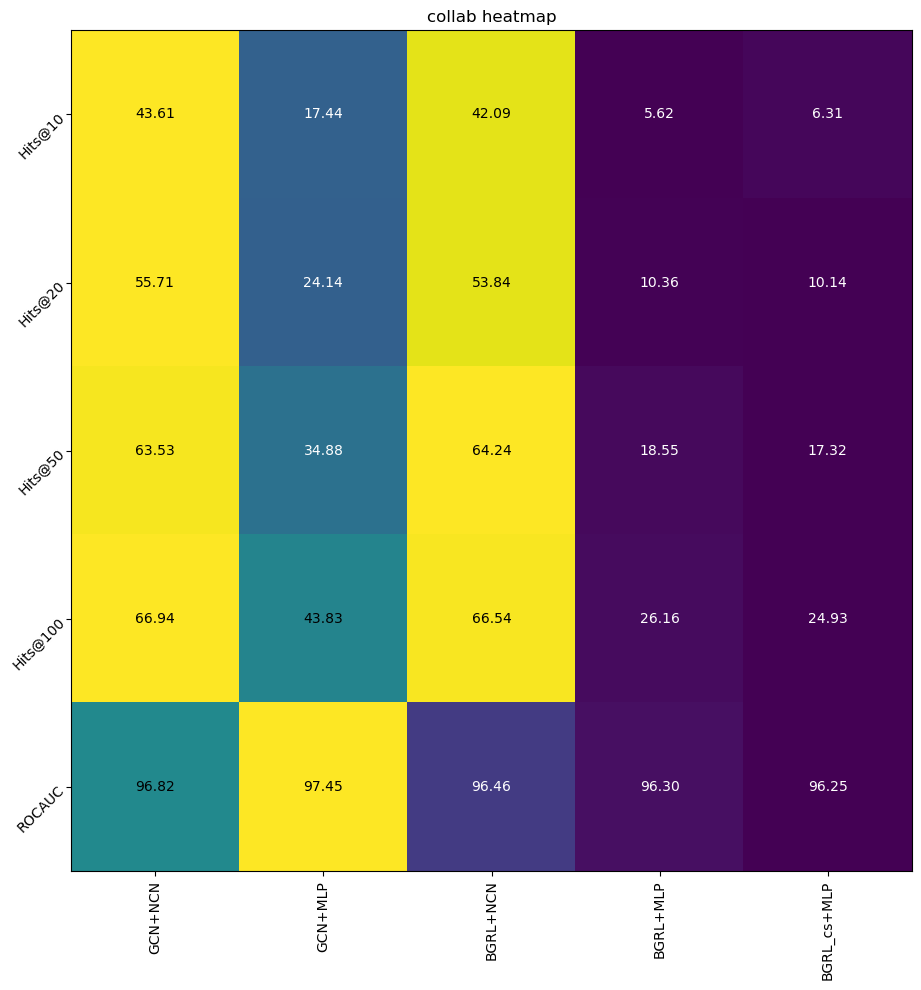

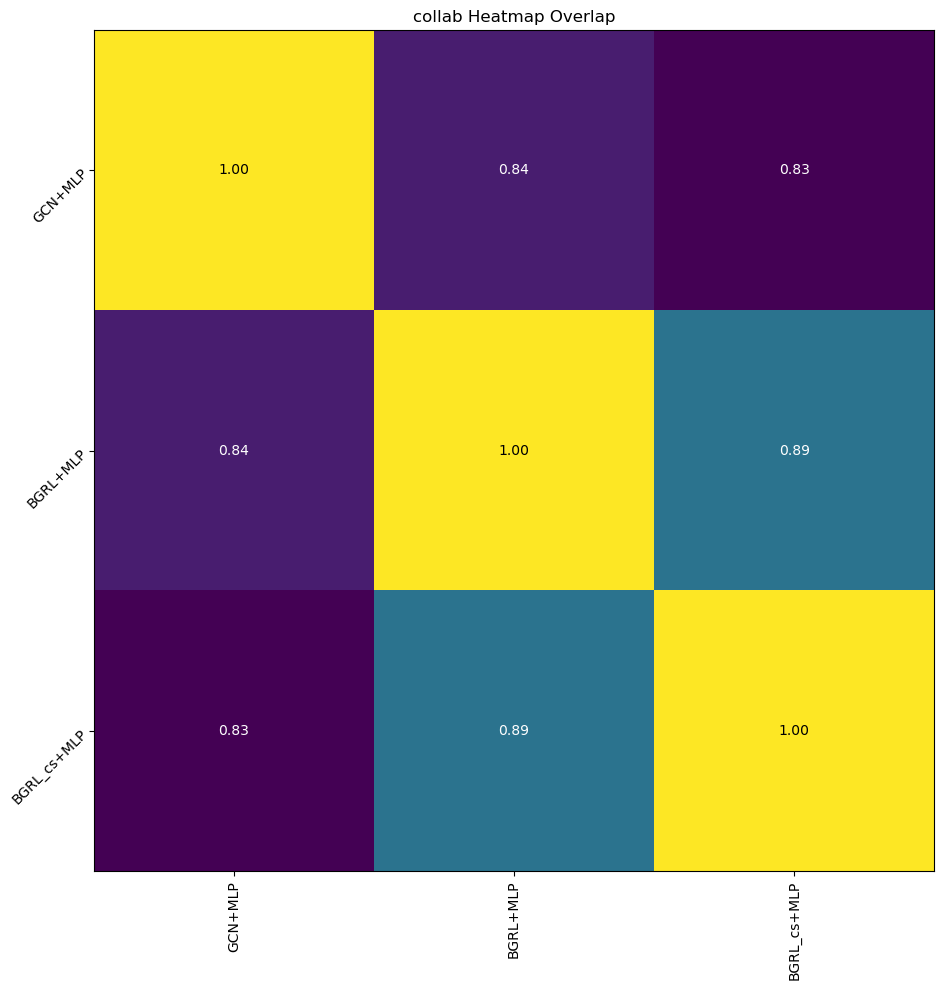

In [13]:
# Overlaps
data4 = pd.read_csv('./collab_res.csv', sep=';').T
data4.columns = data4.loc['metrics']
data4.drop(index='metrics', inplace=True)
pred = data4['test_pred'].apply(ast.literal_eval)
pred.index = pred.index.str.replace('collab ', '', regex=False)

data4.drop(columns='test_pred', inplace=True)
data4.index = data4.index.str.replace('collab ', '', regex=False)
print('collab')
print(data4.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data4, 'collab heatmap')
def jaccard_sim(data1, data2):
    data1 = np.array(data1)
    data2 = np.array(data2)
    # data1 = (data1 - data1.min()) / (data1.max() - data1.min())
    # data2 = (data2 - data2.min()) / (data2.max() - data2.min())
    return jaccard_score([x>0.5 for x in data1], [x>0.5 for x in data2])

def jaccard_heatmap(data4):
    data4 = data4[~data4.index.str.contains('NCN')]
    res = np.zeros((len(data4), len(data4)))
    for idx in range(len(data4)):
        for idx2 in range(len(data4)):
            if idx < idx2:
                res[idx][idx2] = jaccard_sim(data4.iloc[idx], data4.iloc[idx2])
    res += np.transpose(res) + np.identity(len(data4))
    heatmap(pd.DataFrame(res, index=data4.index, columns=data4.index), 'collab Heatmap Overlap', False)

jaccard_heatmap(pred)

## SBM_res

SBM
\begin{tabular}{lllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
\midrule
SBM_GRACE+MLP & 55.22$\pm$4.98 & 74.06$\pm$3.78 & 95.44$\pm$2.03 & 99.93$\pm$0.09 & 97.35$\pm$0.2 & 59.02$\pm$4.88 \\
SBM_BGRL+MLP & 50.77$\pm$5.19 & 71.94$\pm$3.63 & 95.13$\pm$2.18 & 99.24$\pm$0.29 & 96.99$\pm$0.24 & 49.95$\pm$2.63 \\
SBM_GRACE+Inner & 3.19$\pm$2.35 & 9.15$\pm$6.56 & 45.65$\pm$16.79 & 99.82$\pm$0.22 & 91.11$\pm$1.11 & 60.99$\pm$3.37 \\
SBM_BGRL+Inner & 48.52$\pm$6.72 & 62.47$\pm$2.67 & 63.91$\pm$1.62 & 64.48$\pm$1.49 & 78.25$\pm$2.51 & 51.58$\pm$2.72 \\
GCN+NCN & 56.0$\pm$3.68 & 74.82$\pm$3.83 & 95.13$\pm$2.08 & 99.78$\pm$0.14 & 97.31$\pm$0.22 & nan$\pm$nan \\
GCN+MLP & 57.25$\pm$4.67 & 74.21$\pm$3.39 & 95.63$\pm$1.38 & 99.59$\pm$0.44 & 97.3$\pm$0.23 & nan$\pm$nan \\
GRACE+NCN & 56.72$\pm$3.6 & 72.36$\pm$3.67 & 95.7$\pm$1.34 & 99.52$\pm$0.51 & 97.17$\pm$0.42 & 8.22$\pm$0.45 \\
GRACE+MLP & 53.65$\pm$5.1 & 71.79$\pm$3.49 & 95.02$\pm$1.87 & 99.37$\p

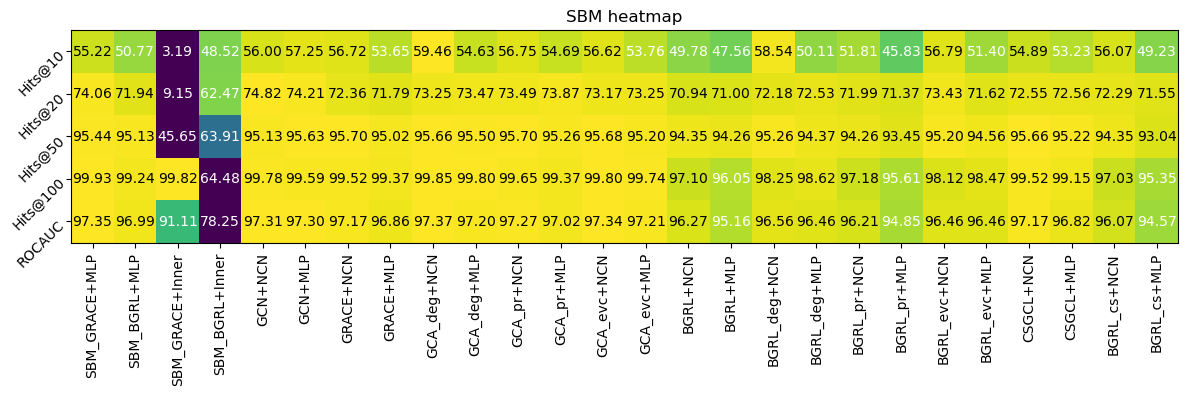

In [19]:
data_sbm = pd.read_csv('./SBM_res.csv', sep=';').T
data_sbm.columns = data_sbm.loc['metrics']
data_sbm.drop(index='metrics', inplace=True)
data_sbm.index = data_sbm.index.str.replace('Cora ', '', regex=False)
print('SBM')
print(data_sbm.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data_sbm, 'SBM heatmap')

SBM
\begin{tabular}{lllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
\midrule
SBM_GRACE+Inner & 3.19$\pm$2.35 & 9.13$\pm$6.58 & 45.61$\pm$16.78 & 99.82$\pm$0.22 & 91.11$\pm$1.11 & 54.04$\pm$3.41 \\
SBM_BGRL+Inner & 52.84$\pm$5.88 & 63.36$\pm$1.76 & 63.78$\pm$1.63 & 64.17$\pm$1.6 & 77.56$\pm$2.22 & 50.25$\pm$2.89 \\
SBM_CSGCL+inner & 3.58$\pm$1.52 & 8.69$\pm$4.0 & 44.72$\pm$17.16 & 99.85$\pm$0.11 & 90.97$\pm$0.82 & 146.14$\pm$3.99 \\
SBM_CSGCL2+inner & 2.99$\pm$1.12 & 6.61$\pm$2.71 & 41.31$\pm$13.39 & 96.51$\pm$9.42 & 90.35$\pm$1.18 & 77.24$\pm$4.38 \\
GCN+inner & 52.55$\pm$10.45 & 74.48$\pm$3.93 & 95.61$\pm$2.3 & 99.85$\pm$0.11 & 97.25$\pm$0.22 & nan$\pm$nan \\
GRACE+inner & 5.83$\pm$5.16 & 14.43$\pm$9.66 & 57.32$\pm$15.46 & 96.42$\pm$2.63 & 90.95$\pm$1.54 & 7.93$\pm$0.55 \\
GCA_deg+inner & 6.57$\pm$3.32 & 14.59$\pm$4.97 & 71.25$\pm$24.19 & 96.83$\pm$3.87 & 92.03$\pm$1.83 & 8.47$\pm$0.4 \\
GCA_pr+inner & 3.38$\pm$2.7 & 9.02$\pm$5.72 & 54.69

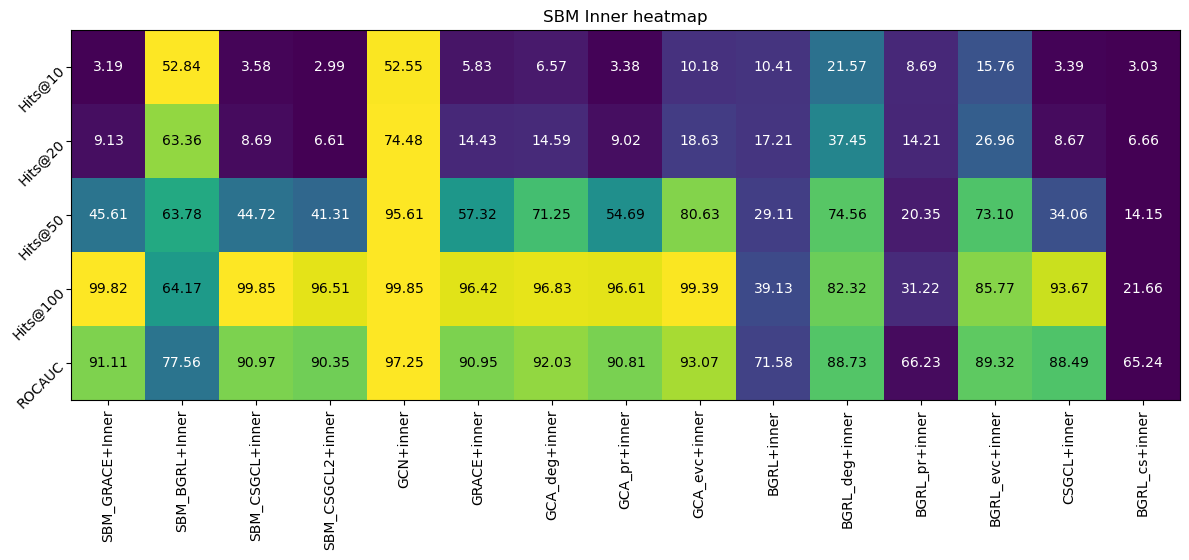

In [20]:
data_sbm_inner = pd.read_csv('./SBM_inner_250_res.csv', sep=';').T
data_sbm_inner.columns = data_sbm_inner.loc['metrics']
data_sbm_inner.drop(index='metrics', inplace=True)
data_sbm_inner.index = data_sbm_inner.index.str.replace('Cora ', '', regex=False)
print('SBM')
print(data_sbm_inner.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data_sbm_inner, 'SBM Inner heatmap')

SBM
\begin{tabular}{lllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
\midrule
SBM_GRACE+Inner & 87.67$\pm$11.11 & 95.81$\pm$1.89 & 97.44$\pm$1.45 & 100.0$\pm$0.0 & 92.41$\pm$2.31 & nan$\pm$nan \\
SBM_BGRL+Inner & 20.81$\pm$9.45 & 55.35$\pm$9.33 & 93.72$\pm$3.3 & 100.0$\pm$0.0 & 74.78$\pm$3.19 & nan$\pm$nan \\
SBM_CSGCL+inner & 87.67$\pm$11.11 & 95.81$\pm$1.89 & 97.44$\pm$1.45 & 100.0$\pm$0.0 & 92.41$\pm$2.31 & nan$\pm$nan \\
SBM_CSGCL2+inner & 87.67$\pm$11.11 & 95.81$\pm$1.89 & 97.44$\pm$1.45 & 100.0$\pm$0.0 & 92.41$\pm$2.31 & nan$\pm$nan \\
GCN+inner & 10.12$\pm$4.03 & 25.12$\pm$6.35 & 63.6$\pm$7.17 & 100.0$\pm$0.0 & 53.11$\pm$4.77 & nan$\pm$nan \\
GRACE+inner & 87.67$\pm$11.11 & 95.81$\pm$1.89 & 97.44$\pm$1.45 & 100.0$\pm$0.0 & 92.41$\pm$2.31 & nan$\pm$nan \\
GCA_deg+inner & 87.67$\pm$11.11 & 95.81$\pm$1.89 & 97.44$\pm$1.45 & 100.0$\pm$0.0 & 92.41$\pm$2.31 & nan$\pm$nan \\
GCA_pr+inner & 87.67$\pm$11.11 & 95.81$\pm$1.89 & 97.44$\pm$1.45 &

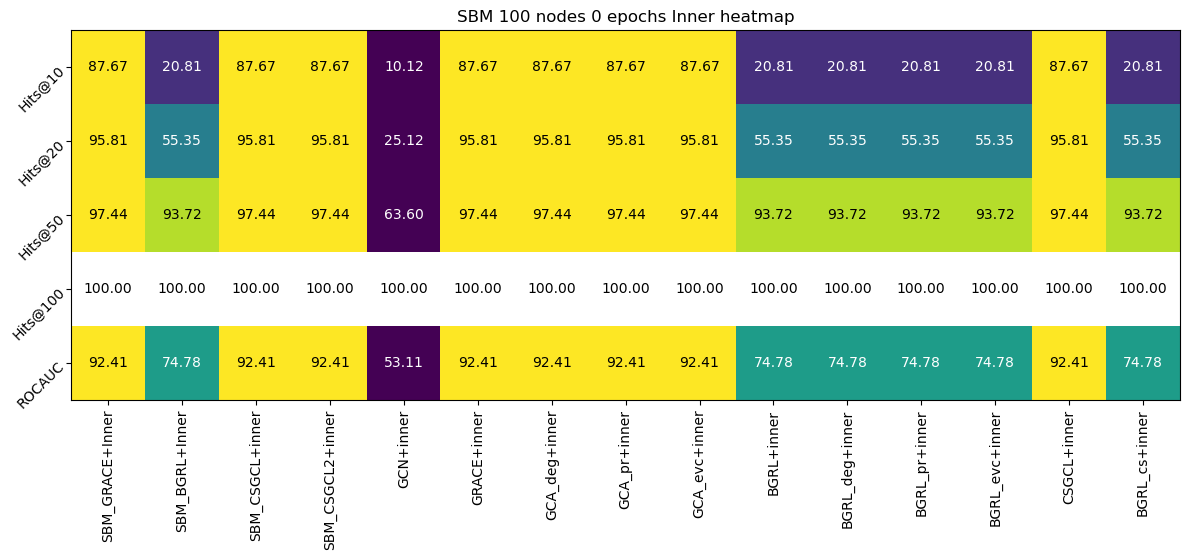

In [21]:
data_sbm_inner_100_0epoch = pd.read_csv('./SBM_inner_0_res.csv', sep=';').T
data_sbm_inner_100_0epoch.columns = data_sbm_inner_100_0epoch.loc['metrics']
data_sbm_inner_100_0epoch.drop(index='metrics', inplace=True)
data_sbm_inner_100_0epoch.index = data_sbm_inner_100_0epoch.index.str.replace('Cora ', '', regex=False)
print('SBM')
print(data_sbm_inner_100_0epoch.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data_sbm_inner_100_0epoch, 'SBM 100 nodes 0 epochs Inner heatmap')

SBM
\begin{tabular}{lllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & pretrain_time \\
\midrule
SBM_GRACE+Inner & 10.96$\pm$10.86 & 31.49$\pm$15.68 & 90.79$\pm$6.42 & 97.9$\pm$0.7 & 93.44$\pm$1.28 & nan$\pm$nan \\
SBM_BGRL+Inner & 1.81$\pm$0.58 & 4.56$\pm$1.11 & 13.03$\pm$3.24 & 34.59$\pm$6.66 & 75.21$\pm$3.21 & nan$\pm$nan \\
SBM_CSGCL+inner & 10.96$\pm$10.86 & 31.49$\pm$15.68 & 90.79$\pm$6.42 & 97.9$\pm$0.7 & 93.44$\pm$1.28 & nan$\pm$nan \\
SBM_CSGCL2+inner & 10.96$\pm$10.86 & 31.49$\pm$15.68 & 90.79$\pm$6.42 & 97.9$\pm$0.7 & 93.44$\pm$1.28 & nan$\pm$nan \\
GCN+inner & 0.89$\pm$0.51 & 2.29$\pm$0.62 & 6.75$\pm$1.0 & 17.88$\pm$2.33 & 55.13$\pm$1.78 & nan$\pm$nan \\
GRACE+inner & 10.96$\pm$10.86 & 31.49$\pm$15.68 & 90.79$\pm$6.42 & 97.9$\pm$0.7 & 93.44$\pm$1.28 & nan$\pm$nan \\
GCA_deg+inner & 10.96$\pm$10.86 & 31.49$\pm$15.68 & 90.79$\pm$6.42 & 97.9$\pm$0.7 & 93.44$\pm$1.28 & nan$\pm$nan \\
GCA_pr+inner & 10.96$\pm$10.86 & 31.49$\pm$15.68 & 90.79$\pm$6.42 & 

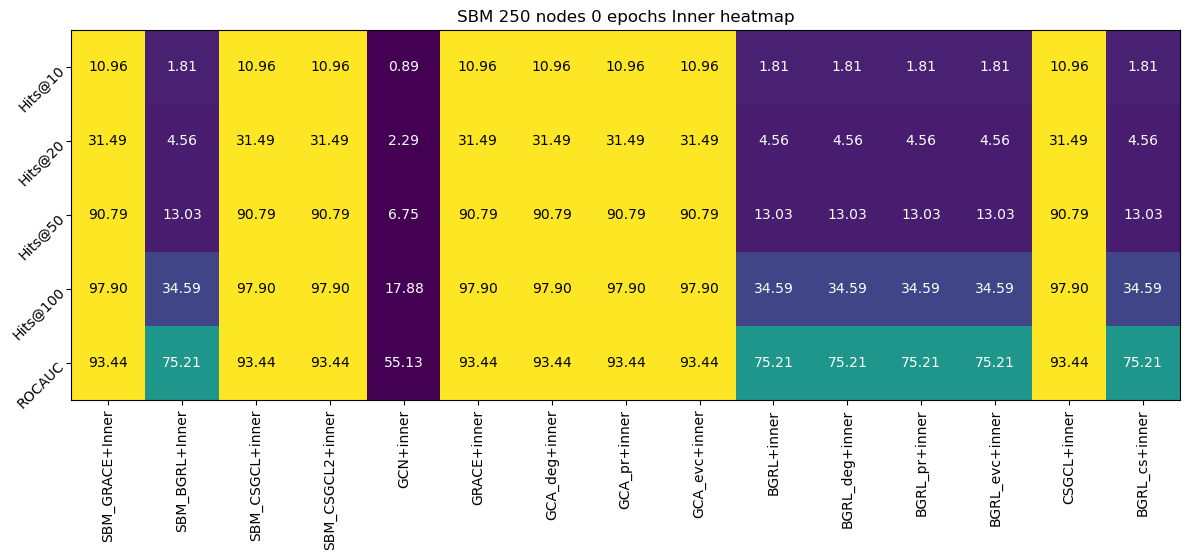

In [22]:
data_sbm_inner_250_0epoch = pd.read_csv('./SBM_inner_250_0_res.csv', sep=';').T
data_sbm_inner_250_0epoch.columns = data_sbm_inner_250_0epoch.loc['metrics']
data_sbm_inner_250_0epoch.drop(index='metrics', inplace=True)
data_sbm_inner_250_0epoch.index = data_sbm_inner_250_0epoch.index.str.replace('Cora ', '', regex=False)
print('SBM')
print(data_sbm_inner_250_0epoch.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data_sbm_inner_250_0epoch, 'SBM 250 nodes 0 epochs Inner heatmap')